In [3]:
!pip install matplotlib
!pip install scikit-learn
!pip install imbalanced-learn


[notice] A new release of pip is available: 24.3.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 24.3.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 24.3.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier

In [80]:
import importlib
import utils

# Принудительно обновляем utils в памяти
importlib.reload(utils)

from utils import merge_files_with_agg, drop_columns, overview

In [94]:
# ── 1 postings
DATA_PATH = 'data/'
df = pd.read_csv(DATA_PATH + 'salaries.csv')
print(f'  postings: {df.shape}')
print(f'  Колонки: {df.columns.tolist()}')
display(df.head(10).T)

  postings: (40785, 8)
  Колонки: ['salary_id', 'job_id', 'max_salary', 'med_salary', 'min_salary', 'pay_period', 'currency', 'compensation_type']


,0,1,2,3,4,5,6,7,8,9
salary_id,1,2,3,4,5,6,7,8,9,10
job_id,3884428798,3887470552,3884431523,3884911725,3887473220,3884432468,3884915161,3884428983,3884433248,3884429625
max_salary,NaN,25.0,120000.0,200000.0,35.0,NaN,80000.0,101000.0,55.0,100000.0
med_salary,20.0,NaN,NaN,NaN,NaN,48.43,NaN,NaN,NaN,NaN
min_salary,NaN,23.0,100000.0,10000.0,33.0,NaN,50000.0,84000.0,50.0,72000.0
pay_period,HOURLY,HOURLY,YEARLY,YEARLY,HOURLY,HOURLY,YEARLY,YEARLY,HOURLY,YEARLY
currency,USD,USD,USD,USD,USD,USD,USD,USD,USD,USD
compensation_type,BASE_SALARY,BASE_SALARY,BASE_SALARY,BASE_SALARY,BASE_SALARY,BASE_SALARY,BASE_SALARY,BASE_SALARY,BASE_SALARY,BASE_SALARY


In [95]:
# Шаг 1: Обрабатываем файлы
job_files = [['benefits'], ['job_industries'], ['job_skills'], ['postings']]
for c in job_files:
    df = merge_files_with_agg(df, c, key_column='job_id')
    print(f'  : {df.shape}')
    print(f'  Колонки: {df.columns.tolist()}')

Загружаю benefits.csv...
  Исходный размер benefits: (67943, 3)
  [!] Найдено несколько строк на один job_id. Агрегирую данные...
  Итоговый размер df: (40785, 11)
──────────────────────────────────────────────────
  : (40785, 11)
  Колонки: ['salary_id', 'job_id', 'max_salary', 'med_salary', 'min_salary', 'pay_period', 'currency', 'compensation_type', 'benefits_inferred', 'benefits_type', 'benefits_count']
Загружаю job_industries.csv...
  Исходный размер job_industries: (164808, 2)
  [!] Найдено несколько строк на один job_id. Агрегирую данные...
  Итоговый размер df: (40785, 13)
──────────────────────────────────────────────────
  : (40785, 13)
  Колонки: ['salary_id', 'job_id', 'max_salary', 'med_salary', 'min_salary', 'pay_period', 'currency', 'compensation_type', 'benefits_inferred', 'benefits_type', 'benefits_count', 'job_industries_industry_id', 'job_industries_count']
Загружаю job_skills.csv...
  Исходный размер job_skills: (213768, 2)
  [!] Найдено несколько строк на один job_

In [96]:
df.columns

Index(['salary_id', 'job_id', 'max_salary', 'med_salary', 'min_salary',
       'pay_period', 'currency', 'compensation_type', 'benefits_inferred',
       'benefits_type', 'benefits_count', 'job_industries_industry_id',
       'job_industries_count', 'job_skills_skill_abr', 'job_skills_count',
       'postings_company_name', 'postings_title', 'postings_description',
       'postings_max_salary', 'postings_pay_period', 'postings_location',
       'postings_company_id', 'postings_views', 'postings_med_salary',
       'postings_min_salary', 'postings_formatted_work_type',
       'postings_applies', 'postings_original_listed_time',
       'postings_remote_allowed', 'postings_job_posting_url',
       'postings_application_url', 'postings_application_type',
       'postings_expiry', 'postings_closed_time',
       'postings_formatted_experience_level', 'postings_skills_desc',
       'postings_listed_time', 'postings_posting_domain', 'postings_sponsored',
       'postings_work_type', 'postings_

In [97]:
df.columns = ['salary_id', 'job_id', 'max_salary', 'med_salary', 'min_salary',
'salaries_pay_period', 'salaries_currency', 'salaries_compensation_type', 'benefits_inferred',
'benefits_type', 'benefits_count', 'job_industries_industry_id',
'job_industries_count', 'job_skills_skill_abr', 'job_skills_count',
'company_name', 'title', 'description',
'postings_max_salary', 'postings_pay_period', 'location',
'company_id', 'views', 'postings_med_salary',
'postings_min_salary', 'formatted_work_type',
'applies', 'original_listed_time',
'remote_allowed', 'job_posting_url',
'application_url', 'application_type',
'expiry', 'closed_time',
'formatted_experience_level', 'skills_desc',
'listed_time', 'posting_domain', 'sponsored',
'work_type', 'currency', 'compensation_type',
'normalized_salary', 'zip_code', 'fips']
df.columns

Index(['salary_id', 'job_id', 'max_salary', 'med_salary', 'min_salary',
       'salaries_pay_period', 'salaries_currency',
       'salaries_compensation_type', 'benefits_inferred', 'benefits_type',
       'benefits_count', 'job_industries_industry_id', 'job_industries_count',
       'job_skills_skill_abr', 'job_skills_count', 'company_name', 'title',
       'description', 'postings_max_salary', 'postings_pay_period', 'location',
       'company_id', 'views', 'postings_med_salary', 'postings_min_salary',
       'formatted_work_type', 'applies', 'original_listed_time',
       'remote_allowed', 'job_posting_url', 'application_url',
       'application_type', 'expiry', 'closed_time',
       'formatted_experience_level', 'skills_desc', 'listed_time',
       'posting_domain', 'sponsored', 'work_type', 'currency',
       'compensation_type', 'normalized_salary', 'zip_code', 'fips'],
      dtype='str')

In [98]:
company_files = ['companies', 'company_industries', 'company_specialities']
df = merge_files_with_agg(df, company_files, key_column='company_id')

Загружаю companies.csv...
  Исходный размер companies: (24473, 10)
  Дубликатов по company_id нет, агрегация не требуется.
  Итоговый размер df: (40785, 54)
──────────────────────────────────────────────────
Загружаю company_industries.csv...
  Исходный размер company_industries: (24375, 2)
  [!] Найдено несколько строк на один company_id. Агрегирую данные...
  Итоговый размер df: (40785, 56)
──────────────────────────────────────────────────
Загружаю company_specialities.csv...
  Исходный размер company_specialities: (169387, 2)
  [!] Найдено несколько строк на один company_id. Агрегирую данные...
  Итоговый размер df: (40785, 58)
──────────────────────────────────────────────────


In [99]:
# тут
df.to_csv('df.csv')
df = pd.read_csv('df.csv')

# exel
#df_no_de = drop_columns(df, ['description', 'companies_description', 'companies_address'])
#df_no_de.to_excel('df_no_de.xlsx')


In [100]:
df.head().T

,0,1,2,3,4
Unnamed: 0,0,1,2,3,4
salary_id,1,2,3,4,5
job_id,3884428798,3887470552,3884431523,3884911725,3887473220
max_salary,NaN,25.0,120000.0,200000.0,35.0
med_salary,20.0,NaN,NaN,NaN,NaN
min_salary,NaN,23.0,100000.0,10000.0,33.0
salaries_pay_period,HOURLY,HOURLY,YEARLY,YEARLY,HOURLY
salaries_currency,USD,USD,USD,USD,USD
salaries_compensation_type,BASE_SALARY,BASE_SALARY,BASE_SALARY,BASE_SALARY,BASE_SALARY
benefits_inferred,NaN,NaN,0,NaN,NaN


In [109]:
overview(df)

,dtype,count,missing_n,missing_%,uniques_n,uniques
max_salary,float64,33947,6838,16.765968,5321,"[nan, 25.0, 120000.0, 200000.0, 35.0, 80000.0,..."
med_salary,float64,6838,33947,83.234032,1417,"[20.0, nan, 48.43, 105000.0, 25.0, 85000.0, 40..."
min_salary,float64,33947,6838,16.765968,4620,"[nan, 23.0, 100000.0, 10000.0, 33.0, 50000.0, ..."
salaries_pay_period,str,40785,0,0.000000,5,"[HOURLY, YEARLY, MONTHLY, WEEKLY, BIWEEKLY]"
salaries_currency,str,40785,0,0.000000,6,"[USD, CAD, BBD, EUR, AUD, GBP]"
benefits_inferred,str,11827,28958,71.001594,3,"[nan, 0, 1, 0, 1]"
benefits_type,str,11827,28958,71.001594,689,"[nan, Medical insurance, Vision insurance, Den..."
benefits_count,float64,11827,28958,71.001594,12,"[nan, 4.0, 5.0, 6.0, 11.0, 1.0, 2.0, 7.0, 3.0,..."
job_industries_industry_id,str,40417,368,0.902293,3440,"[82, 54, 56, 12, 17, 15, 43, 104, 96, 4, 8, 13..."
job_industries_count,float64,40417,368,0.902293,3,"[1.0, 3.0, 2.0, nan]"


In [102]:
# Проверка: абсолютно ли одинаковые столбцы col1 и col2?
is_equal = df['company_name'].equals(df['companies_name'])
print(f"Столбцы идентичны: {is_equal}")




Столбцы идентичны: True


In [108]:
# удалеем Unnamed, salary_id, job_id - лишнее
# companies_name - дубль, pay_period, compensation_type - дубль
# max_salary, med_salary, min_salary - хуже чем в салари
# salaries_compensation_type только одно значение BASE_SALARY
# zip_code, fips, companies_address, companies_zip_code, companies_city, companies_url- много значений
df = drop_columns(df, ['Unnamed: 0', 'salary_id', 'job_id', 'companies_name', 'postings_max_salary', 'postings_med_salary', 'postings_min_salary', 'postings_pay_period', 'compensation_type',
                       'salaries_compensation_type', 'zip_code', 'fips', 'companies_address', 'companies_zip_code', 'companies_city', 'companies_url'])






# можно обработать позже: company_specialities_speciality
df = drop_columns(df, ['company_specialities_speciality', ''])

In [ ]:
df.columns



In [21]:
# Потом заменить
#df_skills = pd.read_csv(DATA_PATH + 'skills.csv')
#skills_dict = df_skills.set_index('skill_abr')['skill_name'].to_dict()
#df['job_skills_skill_name'] = df['job_skills_skill_abr'].map(skills_dict)

#df_industries = pd.read_csv(DATA_PATH + 'industries.csv')
#industry_dict = df_industries.set_index('industry_id')['industry_name'].to_dict()
#df['job_industries_industry_id'] = df['job_industries_industry_id'].map(industry_dict)
#industry_dict


In [23]:
display(df.shape)
display(df.info())
display(df.duplicated().sum())

(40785, 59)

<class 'pandas.DataFrame'>
RangeIndex: 40785 entries, 0 to 40784
Data columns (total 59 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   Unnamed: 0                           40785 non-null  int64  
 1   salary_id                            40785 non-null  int64  
 2   job_id                               40785 non-null  int64  
 3   max_salary                           33947 non-null  float64
 4   med_salary                           6838 non-null   float64
 5   min_salary                           33947 non-null  float64
 6   pay_period                           40785 non-null  str    
 7   currency                             40785 non-null  str    
 8   compensation_type                    40785 non-null  str    
 9   benefits_inferred                    11827 non-null  str    
 10  benefits_type                        11827 non-null  str    
 11  benefits_count                       11

None

np.int64(0)

In [352]:
for c in ['expiry', 'closed_time', 'listed_time', 'original_listed_time']:
    df[c] = pd.to_datetime(df[c], unit='ms')


Столбцы идентичны: True
Столбцы идентичны: True
Столбцы идентичны: True
Столбцы идентичны: True
Столбцы идентичны: True
Столбцы идентичны: True
Столбцы идентичны: False


In [355]:
# колонки с id, url, кроме job_id
df = drop_columns(df, ['company_id', 'job_posting_url', 'job_posting_url', 'companies_url', 'salaries_salary_id'])

# колонки с много текста, потом вернуть
#df = drop_columns(df, ['skills_desc', 'companies_address', 'description', 'companies_description', 'company_specialities_speciality'])

# удаление дублей
df = drop_columns(df, ['companies_name', 'salaries_max_salary', 'salaries_med_salary', 'salaries_min_salary', 'salaries_compensation_type', 'work_type'])

# пока не исследованы
df = drop_columns(df, ['zip_code', 'fips', 'companies_state', 'companies_city', 'companies_zip_code', 'salaries_pay_period'])

In [356]:
# Создаем новые столбцы 'city' и 'state'
# Разделяем по запятой, n=1 означает "сделать только один разрез"
df[['city', 'state']] = df['location'].str.split(',', n=1, expand=True)

# --- Наводим красоту и чистим данные ---

# 1. Убираем лишние пробелы по краям в обоих столбцах
df['city'] = df['city'].str.strip()
df['state'] = df['state'].str.strip()

# 2. Убираем "United States " из названий городов, если оно там есть
df['city'] = df['city'].str.replace('United States ', '', regex=False)

# Смотрим на результат
print(df[['location', 'city', 'state']].head(10))

            location           city state
0      Princeton, NJ      Princeton    NJ
1   Fort Collins, CO   Fort Collins    CO
2     Cincinnati, OH     Cincinnati    OH
3  New Hyde Park, NY  New Hyde Park    NY
4     Burlington, IA     Burlington    IA
5        Raleigh, NC        Raleigh    NC
6      United States  United States   NaN
7  San Francisco, CA  San Francisco    CA
8          Omaha, NE          Omaha    NE
9       Palm Bay, FL       Palm Bay    FL


In [357]:
# инфа извлечена
df = drop_columns(df, ['location'])

# много категорий
df = drop_columns(df, ['city'])

In [358]:
df['med_salary_'] = df['med_salary'].fillna(
    (df['min_salary'] + df['max_salary']) / 2
)

# новая фича ширина вилки зарплат
df['salary_range'] = df['max_salary'] - df['min_salary']



In [359]:
# тогда другие salary удаляем
df = drop_columns(df, ['max_salary', 'min_salary'])

In [360]:
print(f'Строк с зарплатой (med_salary): {df['med_salary_'].notna().sum():,}')
print(f'Строк без зарплаты:             {df['med_salary_'].isna().sum():,}')
print(f'% с зарплатой: {df['med_salary_'].notna().mean()*100:.1f}%')
df = df.dropna(subset=['med_salary_'])

Строк с зарплатой (med_salary): 36,073
Строк без зарплаты:             87,776
% с зарплатой: 29.1%


In [361]:
## 2. Нормализация зарплат
# Зарплаты хранятся в разных единицах: `HOURLY`, `MONTHLY`, `YEARLY`.
# Приводим всё к **годовой зарплате в USD** перед любым анализом.
def normalize_salary(row):
    salary = row.get('med_salary_')
    period = str(row.get('pay_period', '')).upper()
    if pd.isna(salary):
        return np.nan
    if period == 'HOURLY':
        return salary * 2080
    elif period == 'WEEKLY':
        return salary * 52
    elif period == 'BIWEEKLY':
        return salary * 26
    elif period == 'MONTHLY':
        return salary * 12
    elif period == 'YEARLY':
        return salary * 1
    else:  # YEARLY или пусто
        return salary

df['target_salary'] = df.apply(normalize_salary, axis=1)

In [362]:
def validate_salary_adequacy(row):
    salary = row.get('target_salary')
    work_type = str(row.get('formatted_work_type', '')).strip().lower()
    
    # 1. Проверка на пустые или некорректные числа
    if pd.isna(salary) or salary <= 0:
        return pd.Series(['low', 'invalid'])
    
    # 2. Критически огромные значения (Выбросы / Ошибки ввода)
    if salary > 1_000_000:
        return pd.Series(['low', 'out_of_range'])
    
    if salary > 500_000:
        return pd.Series(['medium', 'extreme_high'])
        
    # 3. Критически низкие значения (Граница ~ $15,000 в год)
    if salary < 15_000:
        # Если это волонтер, стажер или парт-тайм — это нормально
        if work_type in ['internship', 'part-time', 'volunteer', 'temporary']:
            return pd.Series(['medium', 'ok'])
        # Если это фулл-тайм контракт с зп меньше $15к — это подозрительно
        elif work_type == 'full-time':
            return pd.Series(['low', 'extreme_low'])
        # Если тип работы вообще не указан
        else:
            return pd.Series(['low', 'ambiguous'])
            
    # 4. Граница "Серой зоны" (~ $15,000 - $30,000 в год)
    if salary < 30_000:
        if work_type == 'full-time':
            # Для США это маловато, ставим среднюю уверенность
            return pd.Series(['medium', 'ok']) 
        else:
            return pd.Series(['high', 'ok'])
            
    # 5. Стандартная адекватная рыночная зарплата
    return pd.Series(['high', 'ok'])


In [363]:
df[['confidence', 'flag']] = df.apply(validate_salary_adequacy, axis=1)



In [364]:
print("--- Распределение флагов безопасности ---")
print(df['flag'].value_counts())

print("\n--- Уровень уверенности в данных ---")
print(df['confidence'].value_counts())

--- Распределение флагов безопасности ---
flag
ok              35584
extreme_low       262
ambiguous         117
extreme_high       58
out_of_range       38
invalid            14
Name: count, dtype: int64

--- Уровень уверенности в данных ---
confidence
high      35181
medium      461
low         431
Name: count, dtype: int64


In [365]:
df = df[df['flag'] == 'ok']

In [366]:
# def detect_hourly_from_description(description):
#     if pd.isna(description):
#         return False
#     desc = description.lower()
#     # Ищем паттерны почасовой оплаты в тексте
#     patterns = [
#         r'\$[\d,]+\s*(?:per hour|/hr|/hour|an hour|p\.h\.)',
#         r'[\d,]+\s*(?:per hour|/hr|/hour)',
#         r'hourly rate',
#         r'hourly pay',
#         r'hourly wage'
#     ]
#     return any(re.search(p, desc) for p in patterns)

# # Находим проблемные строки
# yearly_mask = df['pay_period'] == 'YEARLY'
# df['desc_says_hourly'] = df['description'].apply(detect_hourly_from_description)

# problematic = df[yearly_mask & df['desc_says_hourly']]
# print(f'Найдено вакансий с конфликтом pay_period vs description: {len(problematic)}')
# print()
# print(problematic[['title', 'target_salary', 'pay_period']].head(10))

In [367]:
# # Исправляем только те где описание подтверждает почасовую ставку
# def fix_salary_smart(row):
#     salary = row['target_salary']
#     period = row['pay_period']
#     desc_hourly = row['desc_says_hourly']
    
#     if period == 'YEARLY' and desc_hourly and salary < 500:
#         return salary * 2080   # конвертируем в годовую
#     return salary

# df['target_salary_fixed'] = df.apply(fix_salary_smart, axis=1)

# # Сравниваем до и после
# fixed_count = (df['target_salary_fixed'] != df['target_salary']).sum()
# print(f'Исправлено строк: {fixed_count}')

In [368]:
SALARY_RANGES = {
    'HOURLY':    (7,    250),      # $7–$250/час (мин. wage – топ специалист)
    'WEEKLY':    (280,  10_000),   # $280–$10k/неделю
    'BIWEEKLY':  (560,  20_000),   # $560–$20k/две недели
    'MONTHLY':   (1_200, 40_000),  # $1.2k–$40k/месяц
    'YEARLY':    (15_000, 500_000) # $15k–$500k/год
}

def guess_pay_period(salary):
    # Если зарплаты нет, то и период угадать нельзя
    if pd.isna(salary):
        return np.nan

    # Проходим по словарю и ищем совпадение по диапазону
    for period, (low, high) in SALARY_RANGES.items():
        if low <= salary <= high:
            return period

    # Если число не попало ни в один диапазон (или попало в стыки, например 260)
    return 'UNKNOWN'


# Применяем функцию к колонке с зарплатой
# ВНИМАНИЕ: Проверяем именно колонку с цифрами зарплаты (например, 'target_salary')
df['pay_period_new'] = df['target_salary'].apply(guess_pay_period)


# Оставляем только те строки, где значения в двух столбцах абсолютно одинаковы
display(df.shape)
df = df[df['pay_period_new'] == df['pay_period']]
display(df.shape)

(35584, 48)

(20014, 48)

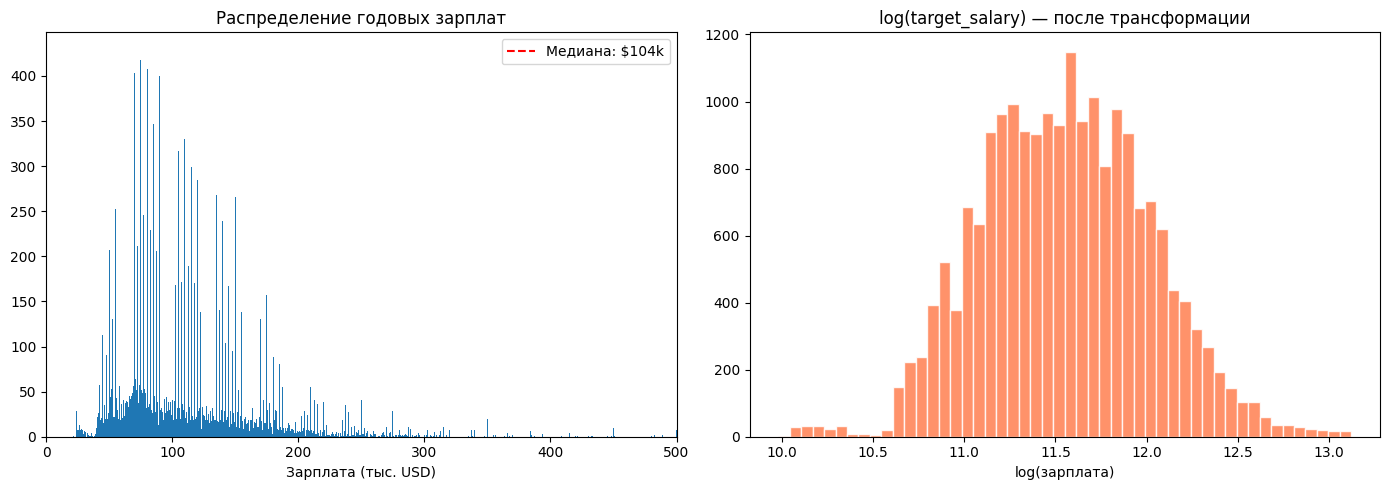

In [369]:
# Распределение зарплат
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['target_salary']/1000, bins=1000) #bins=60
axes[0].set_title('Распределение годовых зарплат')
axes[0].set_xlabel('Зарплата (тыс. USD)')
axes[0].axvline(df['target_salary'].median(),
                color='red', linestyle='--',
                label=f'Медиана: ${df["target_salary"].median()/1000:.0f}k')

axes[0].legend()
axes[0].set_xlim(0, 500)

axes[1].hist(np.log(df['target_salary']+1), bins=50,
             color='coral', edgecolor='white', alpha=0.85)
axes[1].set_title('log(target_salary) — после трансформации')
axes[1].set_xlabel('log(зарплата)')

plt.tight_layout()
plt.show()

In [370]:
#df.describe().T

In [371]:
# print(df[df['job_id'] == 3885842845]['description'].iloc[0])

In [372]:
# # 2. Функция для проверки условий
# def check_work_type(text):
#     if not isinstance(text, str):
#         return None

#     # Приводим к нижнему регистру для точного поиска
#     text_lower = text.lower()

#     # Ищем слова (дефис делаем необязательным с помощью -?)
#     has_full = bool(re.search(r'full-?time', text_lower))
#     has_part = bool(re.search(r'part-?time', text_lower))

#     # Логика записи в колонку
#     if has_full and has_part:
#         return 'Full-time, Part-time'
#     elif has_full:
#         return 'Full-time'
#     elif has_part:
#         return 'Part-time'
#     else:
#         return None  # или 'Not specified'


# # 3. Применяем функцию к DataFrame
# df['formatted_work_type_'] = df['description'].apply(check_work_type)

# # Смотрим результат
# print(df[['description', 'formatted_work_type_']])


In [373]:
# def extract_hours(text):
#     if not isinstance(text, str):
#         return None
    
#     # Регулярное выражение ищет:
#     # 1. Число или диапазон (например: 20 или 15-20)
#     # 2. Необязательные пробелы
#     # 3. Сокращения часов (hours, hour, hrs, hr)
#     # 4. Предлоги и слова "в неделю" (per week, a week, /week, /wk)
#     pattern = r'(\d+(?:-\d+)?)\s*(?:hours|hour|hrs|hr)\s*(?:per\s+week|a\s+week|/week|/wk)'
    
#     match = re.search(pattern, text, re.IGNORECASE)
    
#     if match:
#         # Возвращает найденное число или диапазон (например, '20' или '15-20')
#         return match.group(1)
        
#     return None

# # Применяем функцию к DataFrame
# df['hours_per_week'] = df['description'].apply(extract_hours)

# # Смотрим результат
# print(df[['description', 'hours_per_week']])

In [374]:
# # 2. Функция исправления валюты
# def fix_currency(row):
#     # Проверяем, что в описании есть текст и он содержит знак фунта £
#     if isinstance(row['description'], str) and '£' in row['description']:
#         return 'GBP'
    
#     # Если знака £ нет, возвращаем текущую валюту без изменений
#     return row['currency']

# # 3. Применяем функцию по строкам (axis=1)
# df['currency'] = df.apply(fix_currency, axis=1)
# display(df[df['currency'] == 'USD'])


# # Оставляем только те строки, где значения валюты доллар
# df = df[df['currency'] == 'USD']

In [375]:
df['application_url'] = np.where(df['application_url'].notna(), 1, 0)


for c in ['views', 'remote_allowed', 'applies', 'companies_company_size', 'companies_company_size', 'formatted_experience_level', 'companies_country',
          'company_industries_count', 'company_specialities_count', 'benefits_count', 'job_industries_count', 'job_skills_count']:
    df[c] = df[c].fillna(0)


df['state'] = np.where(df['state'].str.len() > 2, '0', df['state'])


# 1 — вилка была указана, 0 — вилки не было (пропуск / нд)
df['has_salary_range'] = df['salary_range'].notna().astype(int)



In [376]:
# ФИЧА ИНЖИНИРИН

In [377]:
# время жизни вакансии
df['vacancy_lifetime_days'] = (df['expiry'] - df['original_listed_time']).dt.total_seconds() / (24 * 3600)

# 1. Создаем  три бинарных флага вакансия живет 30 дней, меньше или больше
df['lifetime_short'] = (df['vacancy_lifetime_days'] < 29).astype(int)
df['lifetime_standard'] = df['vacancy_lifetime_days'].round().isin([29, 30, 31]).astype(int)
df['lifetime_long'] = (df['vacancy_lifetime_days'] > 31).astype(int)

# 2. Оставляем исходное число дней, но сглаживаем логарифмом, 
# чтобы выброс в 179 дней не тянул одеяло на себя
#######################df['vacancy_lifetime_log'] = np.log1p(df['vacancy_lifetime_days'])

# Месяц публикации (от 1 до 12) — покажет сезонность найма
df['listed_month'] = df['original_listed_time'].dt.month

# Квартал (от 1 до 4) — часто привязан к финансовым бюджетам компаний
df['listed_quarter'] = df['original_listed_time'].dt.quarter

# День недели (0 - понедельник, 6 - воскресенье)
# Вакансии, выложенные в выходные, часто публикуются небольшими компаниями вручную
df['listed_day_of_week'] = df['original_listed_time'].dt.dayofweek
df['is_posted_on_weekend'] = df['listed_day_of_week'].isin([5, 6]).astype(int)


# Извлекаем час публикации
df['listed_hour'] = df['original_listed_time'].dt.hour

# Создаем маркер: ночная автоматическая публикация (например, с 00:00 до 06:00)
# флаг авто публикации или человеком от времени
df['is_night_posting'] = df['listed_hour'].between(0, 6).astype(int)


# Флаг: была ли вакансия переопубликована/обновлена
# (разница больше 1 часа, чтобы отсечь технические задержки парсера)
df['is_reposted'] = ((df['listed_time'] - df['original_listed_time']).dt.total_seconds() > 3600).astype(int)

# Сколько дней вакансия «висела» до того, как её решили обновить
df['days_before_repost'] = (df['listed_time'] - df['original_listed_time']).dt.total_seconds() / (24 * 3600)

In [378]:
df.shape

(20014, 61)

In [379]:
df = drop_columns(df, ['company_industry'])

# # 1. Готовим данные: превращаем строку с запятыми в настоящий список Python
# # Важно убрать пробелы с помощью .strip(), чтобы ' IT' и 'IT' объединились
# df['company_industry'] = df['company_industries_industry'].fillna('OTHR').apply(lambda x: [s.strip() for s in x.split(',')])

# # 2. Инициализируем бинаризатор
# mlb = MultiLabelBinarizer()

# # 3. Трансформируем списки в матрицу из 0 и 1
# company_industry_encoded = mlb.fit_transform(df['company_industry'])

# # 4. Превращаем это в красивый датафрейм с именами навыков в качестве колонок
# company_industry_df = pd.DataFrame(
#     company_industry_encoded, 
#     columns=[f"industry_{cls}" for cls in mlb.classes_], 
#     index=df.index
# )

# # 5. Объединяем с основным датафреймом
# print(df.shape)
# df = pd.concat([df, company_industry_df], axis=1)
# print(df.shape)

In [380]:
df = drop_columns(df, ['skills_list'])

# # 1. Готовим данные: превращаем строку с запятыми в настоящий список Python
# # Важно убрать пробелы с помощью .strip(), чтобы ' IT' и 'IT' объединились
# df['skills_list'] = df['job_skills_skill_abr'].fillna('OTHR').apply(lambda x: [s.strip() for s in x.split(',')])

# # 2. Инициализируем бинаризатор
# mlb = MultiLabelBinarizer()

# # 3. Трансформируем списки в матрицу из 0 и 1
# skills_encoded = mlb.fit_transform(df['skills_list'])

# # 4. Превращаем это в красивый датафрейм с именами навыков в качестве колонок
# skills_df = pd.DataFrame(
#     skills_encoded, 
#     columns=[f"skill_{cls}" for cls in mlb.classes_],
#     index=df.index
# )

# # 5. Объединяем с основным датафреймом
# print(df.shape)
# df = pd.concat([df, skills_df], axis=1)
# print(df.shape)

In [381]:
categorical_cols = [
    'pay_period', 
    #'state', 
    'formatted_work_type', 
    'application_type',
    #'formatted_experience_level',
    'companies_company_size',
    #'companies_country',
    #'listed_day_of_week'
]

df[categorical_cols] = df[categorical_cols].astype(str)

# 2. Инициализируем кодировщик
# drop='first' — удаляет первый столбец для защиты от мультиколлинеарности
# sparse_output=False — возвращает обычный массив numpy, а не разреженную матрицу
ohe = OneHotEncoder(drop='first', sparse_output=False, dtype=int)

# 3. Обучаем и трансформируем только категориальные столбцы
encoded_array = ohe.fit_transform(df[categorical_cols])

# 4. Создаем красивый датафрейм из закодированных фичей с правильными именами
encoded_cols_names = ohe.get_feature_names_out(categorical_cols)
df_encoded = pd.DataFrame(encoded_array, columns=encoded_cols_names, index=df.index)

# 5. Собираем всё воедино:
# Удаляем старые категориальные столбцы
df_clean = df.drop(columns=categorical_cols)

# Пристыковываем новые OHE-колонки к очищенному датафрейму
print(df.shape)
df = pd.concat([df_clean, df_encoded], axis=1)
print(df.shape)

# Проверяем результат
print(df.head())

df = drop_columns(df, ['state', 'formatted_experience_level', 'companies_country', 'listed_day_of_week'
                       ])


(20014, 61)
(20014, 74)
   Unnamed: 0.1  Unnamed: 0     job_id            company_name  \
2             2           2   10998357  The National Exemplar    
3             3           3   23221523  Abrams Fensterman, LLP   
4             4           4   35982263                     NaN   
6             6           6  103254301              Raw Cereal   
7             7           7  112576855                     NaN   

                                               title  \
2                        Assitant Restaurant Manager   
3  Senior Elder Law / Trusts and Estates Associat...   
4                                 Service Technician   
6                                           Producer   
7                                  Building Engineer   

                                         description  views  med_salary  \
2  The National Exemplar is accepting application...    8.0         NaN   
3  Senior Associate Attorney - Elder Law / Trusts...   16.0         NaN   
4  Looking for HV

In [382]:
# пока не будем брать
df = drop_columns(df, ['company_name', 'title', 'compensation_type', 'sponsored', 'posting_domain', 'closed_time', 'currency', 'benefits_type', 'benefits_inferred', 'job_industry',
                       'skills_desc', 'companies_address', 'description', 'companies_description', 'company_specialities_speciality',
                       'pay_period_new', 'confidence', 'flag', 'salaries_currency', 'med_salary_', 'normalized_salary',
                       'skills_desc', 'companies_address', 'description', 'companies_description', 'company_specialities_speciality', 'job_industries_industry_id'
                       ])

# взяли все что нужно
df = drop_columns(df, ['expiry', 'listed_time', 'original_listed_time', 'company_industries_industry', 'salary_range', 'company_industry', 'skills_list', 
                       'job_skills_skill_abr', 'med_salary', 'job_id'
                       ])

In [383]:
df[:200].to_excel("output.xlsx", index=False)

In [384]:
# train-test-split
from sklearn.model_selection import train_test_split

def data_split():
    features = df.drop('target_salary', axis=1)
    target = df.loc[:, 'target_salary']

    features_train, features_test, target_train, target_test = train_test_split(features, 
                                                                                target,
                                                                                test_size = 0.1,
                                                                                random_state = 42)
    return features_train, features_test, target_train, target_test



features_train, features_test, target_train, target_test = data_split()


print(f"Dataframe size: {df.shape}")
print(f"Train set size: {features_train.shape}")
print(f"Test set size: {features_test.shape}")
print(f"Train set size: {target_train.shape}")
print(f"Test set size: {target_test.shape}")

features_test.to_csv('features_test.csv', index=False)

Dataframe size: (20014, 41)
Train set size: (18012, 40)
Test set size: (2002, 40)
Train set size: (18012,)
Test set size: (2002,)


In [385]:
def separate_binary_and_numeric(dataframe):
    binary_cols = []
    numeric_cols = []
    
    # Отбираем только числовые типы (int и float), исключая текст и даты
    num_df = dataframe.select_dtypes(include=[np.number])
    
    for col in num_df.columns:
        # Получаем уникальные значения в столбце, удаляя пропуски (NaN)
        unique_vals = dataframe[col].dropna().unique()
        
        # Проверяем, являются ли ВСЕ уникальные значения только нулями и единицами
        # (Проверка set(...) гарантирует, что если в столбце все 0 или все 1, он тоже определится как бинарный)
        if set(unique_vals).issubset({0, 1, 0.0, 1.0}):
            binary_cols.append(col)
        else:
            numeric_cols.append(col)
            
    return binary_cols, numeric_cols

In [386]:
bin_cols, num_cols = separate_binary_and_numeric(features_train)

print("Бинарные столбцы:", bin_cols)
print("Числовые столбцы:", num_cols)

Бинарные столбцы: ['remote_allowed', 'application_url', 'has_salary_range', 'lifetime_short', 'lifetime_standard', 'lifetime_long', 'is_posted_on_weekend', 'is_night_posting', 'is_reposted', 'pay_period_YEARLY', 'formatted_work_type_Full-time', 'formatted_work_type_Internship', 'formatted_work_type_Other', 'formatted_work_type_Part-time', 'formatted_work_type_Temporary', 'formatted_work_type_Volunteer', 'application_type_OffsiteApply', 'application_type_SimpleOnsiteApply', 'application_type_UnknownApply', 'companies_company_size_1.0', 'companies_company_size_2.0', 'companies_company_size_3.0', 'companies_company_size_4.0', 'companies_company_size_5.0', 'companies_company_size_6.0', 'companies_company_size_7.0']
Числовые столбцы: ['Unnamed: 0.1', 'Unnamed: 0', 'views', 'applies', 'company_industries_count', 'company_specialities_count', 'benefits_count', 'job_industries_count', 'job_skills_count', 'vacancy_lifetime_days', 'listed_month', 'listed_quarter', 'listed_hour', 'days_before_rep

In [387]:
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import make_pipeline
from imblearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.impute import SimpleImputer

In [388]:

binary_transformer = Pipeline([('imputer', SimpleImputer(strategy='most_frequent'))])

numeric_transformer = Pipeline([('imputer', SimpleImputer(strategy='median')),
                                ('scaler', StandardScaler())]) 

preprocessor = ColumnTransformer(transformers = [('bin', binary_transformer, bin_cols),
                                                 ('num', numeric_transformer, num_cols)], remainder = 'passthrough') 

In [389]:

model_ridge = Pipeline(steps = [('preprocessor', preprocessor),
                                 ('ridge', Ridge(alpha=1.0))])

# 4. Обучаем на логарифме зарплаты

#model_ridge.fit(features_train, np.ravel(target_train))
model_ridge.fit(features_train, np.log1p(np.ravel(target_train)))

,steps,"[('preprocessor', ...), ('ridge', ...)]"
,transform_input,None
,memory,None
,verbose,False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('bin', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. T

In [390]:
# 1. Получаем предсказания зарплат (если обучали на логарифме, это будут логарифмы)
target_test_pred_ridge = model_ridge.predict(features_test)

# 2. Если вы обучали модель на логарифме зарплаты (y_train_log), 
real_salary_pred = np.expm1(target_test_pred_ridge)

In [391]:
real_salary_pred

array([109148.93022847, 107273.10926796, 111693.30187637, ...,
       109514.11392946, 111605.43327398,  94956.83671955], shape=(2002,))

In [ ]:
y_train_log = np.log1p(target_train)
y_test_log = np.log1p(target_test)

In [395]:
y_train_log

92982     11.119898
22170     11.736077
54281     11.156265
106212    12.577640
20842     11.344507
            ...    
67933     11.407576
71640     11.867104
34260     11.858471
5084      11.605166
95943     10.959558
Name: target_salary, Length: 18012, dtype: float64

In [402]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

def evaluate(y_true, y_pred):
    '''
    Оценка качества модели регрессии (предсказания зарплат)
    '''
    # Округлим предсказания, если там вдруг остались inf или NaN из прошлых шагов
    # (на всякий случай, чтобы код не упал)
    y_pred = np.nan_to_num(y_pred, nan=0.0, posinf=y_true.max(), neginf=0.0)
    
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    
    print("=== Результаты модели регрессии ===")
    print(f"MAE (Средняя ошибка в деньгах): {mae:.2f}")
    print(f"RMSE (Квадратичная ошибка): {rmse:.2f}")
    print(f"R^2 (Качество модели от 0 до 1): {r2:.4f}")

In [403]:
evaluate(target_test, real_salary_pred)

=== Результаты модели регрессии ===
MAE (Средняя ошибка в деньгах): 38776.71
RMSE (Квадратичная ошибка): 54501.50
R^2 (Качество модели от 0 до 1): 0.0486
